# Phase 3: Data Transformation & Feature Engineering
### Detecting Malicious PyPI Packages Using Machine Learning on Package Metadata and Code-Level Features
**CSE437 — Data Science: Coding with Real World Data**

This notebook covers:
1. Loading and inspecting the dataset
2. Missing value handling
3. Encoding categorical/target variables
4. Exploratory Data Analysis (EDA) with visualizations
5. Feature derivation (new engineered features)
6. Normalization / scaling

**Dataset sources:**
- Malicious samples: [github.com/lxyeternal/pypi_malregistry](https://github.com/lxyeternal/pypi_malregistry) (official artifact of the ASE 2023 paper *"An Empirical Study of Malicious Code In PyPI Ecosystem"*)
- Benign samples: PyPI's official package index ([pypi.org/simple/](https://pypi.org/simple/)) and JSON API ([pypi.org](https://pypi.org)), randomly sampled


## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 2. Load Dataset

**If running in Google Colab:** running the cell below will prompt you to upload one file.
Please upload when prompted:
- `pypi_malicious_detection_dataset_v2.csv` (the raw dataset, before cleaning)

**If running locally (Jupyter/VS Code):** make sure the CSV file is in the same folder as
this notebook before running — the upload prompt will be skipped automatically.

**Note:** we deliberately start from the *raw* version of this dataset (before any cleaning),
so that the data cleaning steps in this notebook are genuine and verifiable, not performed
invisibly beforehand.


In [2]:
import os

if not os.path.exists("pypi_malicious_detection_dataset_v2.csv"):
    try:
        from google.colab import files
        print("Please upload: pypi_malicious_detection_dataset_v2.csv")
        uploaded = files.upload()
    except ImportError:
        print("Not running in Colab and file not found locally.")
        print("Please place pypi_malicious_detection_dataset_v2.csv in the same folder as this notebook.")


In [3]:
df = pd.read_csv("pypi_malicious_detection_dataset_v2.csv")

print(f"Raw dataset shape: {df.shape}")
df.head()


Raw dataset shape: (2500, 24)


,has_setup_py,num_files,total_size_bytes,has_eval,has_exec,has_base64_decode,has_subprocess,has_os_system,has_socket,has_requests_call,has_urllib_request,has_env_access,has_setup_cmdclass_override,has_hex_or_b64_blob,has_getattr_dynamic,has_ctypes,has_marshal_pickle,num_non_py_executable_like,py_code_entropy,py_code_length,num_py_files,package_name,label,typosquat_family
0,1,10,17999,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.215,1611,1,selfcraftint,malicious,other
1,1,10,17076,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.210,1578,1,urlvm,malicious,other
2,1,10,152115,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.506,150832,2,settinginmaass,malicious,other
3,1,12,2402,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,4.889,993,2,pytest-tt-ddriven,malicious,other
4,1,10,17616,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.217,1609,1,esqccinfo,malicious,other


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   has_setup_py                 2500 non-null   int64  
 1   num_files                    2500 non-null   int64  
 2   total_size_bytes             2500 non-null   int64  
 3   has_eval                     2500 non-null   int64  
 4   has_exec                     2500 non-null   int64  
 5   has_base64_decode            2500 non-null   int64  
 6   has_subprocess               2500 non-null   int64  
 7   has_os_system                2500 non-null   int64  
 8   has_socket                   2500 non-null   int64  
 9   has_requests_call            2500 non-null   int64  
 10  has_urllib_request           2500 non-null   int64  
 11  has_env_access               2500 non-null   int64  
 12  has_setup_cmdclass_override  2500 non-null   int64  
 13  has_hex_or_b64_blob          

In [5]:
df.describe()


,has_setup_py,num_files,total_size_bytes,has_eval,has_exec,has_base64_decode,has_subprocess,has_os_system,has_socket,has_requests_call,has_urllib_request,has_env_access,has_setup_cmdclass_override,has_hex_or_b64_blob,has_getattr_dynamic,has_ctypes,has_marshal_pickle,num_non_py_executable_like,py_code_entropy,py_code_length,num_py_files
count,2500.00000,2500.000000,2.500000e+03,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2.500000e+03,2500.000000
mean,0.81280,26.520800,7.111237e+05,0.039200,0.124000,0.057600,0.443200,0.056800,0.033200,0.139600,0.082400,0.118000,0.120400,0.43800,0.140800,0.07200,0.015200,0.142800,4.895353,7.901654e+04,9.714000
std,0.39015,184.977184,5.730669e+06,0.194109,0.329647,0.233032,0.496863,0.231506,0.179194,0.346641,0.275028,0.322673,0.325494,0.49624,0.347885,0.25854,0.122372,2.123066,0.524959,4.665342e+05,36.073912
min,0.00000,2.000000,4.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,1.00000,10.000000,1.372475e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,4.637000,1.611000e+03,1.000000
50%,1.00000,10.000000,1.834050e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,4.932000,1.983000e+03,2.000000
75%,1.00000,14.000000,6.722700e+04,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.000000,5.216000,3.294925e+04,5.000000
max,1.00000,8714.000000,9.955167e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,74.000000,6.156000,1.567844e+07,806.000000


## 3. Data Cleaning

This section walks through the real cleaning steps applied to the raw dataset: identifying
and correctly handling a data leakage column, missing value checks, duplicate detection, and
outlier analysis.


### 3.0 Identifying a Data Leakage Column

Before doing anything else, we inspect every column for suspicious patterns. One column,
`typosquat_family`, stands out: it records which popular package (e.g. `requests`, `colorama`)
a malicious sample's name closely resembles — but what value does it hold for **benign**
packages, which were never flagged as typosquats of anything?


In [6]:
print(df["typosquat_family"].value_counts().head(10))
print()
print("Unique typosquat_family values for BENIGN rows only:")
print(df[df["label"] == "benign"]["typosquat_family"].unique())


typosquat_family
other             1357
n/a_benign        1000
requests            40
colorama            20
beautifulsoup4      19
pytorch             17
aiohttp              9
matplotlib           7
simplejson           5
scikit-learn         4
Name: count, dtype: int64

Unique typosquat_family values for BENIGN rows only:
<StringArray>
['n/a_benign']
Length: 1, dtype: str


**This is a data leakage problem.** Every single benign row has the exact same value,
`n/a_benign`, while every malicious row has some other value. If this column were left in as a
model feature, a classifier could trivially learn "if this column equals `n/a_benign`, predict
benign" — achieving near-perfect accuracy that reflects a labeling artifact, not real
malicious-vs-benign code patterns. This would produce a model that looks excellent on this
dataset but fails completely on any real, unseen package (which will never have this column at
all, since it doesn't exist outside our own dataset-construction process).

**The correct fix is not to simply delete the column** — it still contains genuinely useful
information for a different purpose: grouping near-duplicate typosquats together during
train/test splitting, so that (for example) two nearly-identical fake `requests` packages don't
end up split across both the training and test sets, which would let a model "cheat" by
memorizing a near-duplicate it already saw. So we separate it out for that specific purpose,
and remove it from the modeling feature set.


In [7]:
# Preserve typosquat_family separately for leakage-safe train/test grouping later,
# but remove it from the modeling feature set.
groups_df = df[["package_name", "label", "typosquat_family"]].copy()

df = df.drop(columns=["typosquat_family"])
print("typosquat_family removed from modeling features.")
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")


typosquat_family removed from modeling features.
Remaining columns (23): ['has_setup_py', 'num_files', 'total_size_bytes', 'has_eval', 'has_exec', 'has_base64_decode', 'has_subprocess', 'has_os_system', 'has_socket', 'has_requests_call', 'has_urllib_request', 'has_env_access', 'has_setup_cmdclass_override', 'has_hex_or_b64_blob', 'has_getattr_dynamic', 'has_ctypes', 'has_marshal_pickle', 'num_non_py_executable_like', 'py_code_entropy', 'py_code_length', 'num_py_files', 'package_name', 'label']


### 3.1 Missing Value Handling

In [8]:
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": missing_summary,
    "missing_percent": missing_pct.round(2)
})
missing_report[missing_report["missing_count"] > 0] if missing_report["missing_count"].sum() > 0 else print("No missing values found in any column.")


No missing values found in any column.


**Result:** This dataset has no missing (NaN) values in its final form. This is not because
cleaning wasn't needed — it's because the cleaning happened *during dataset construction*,
before this CSV was ever saved, rather than being deferred to this notebook. To make that
cleaning work visible and verifiable, the next three subsections show: (a) how many raw
candidates were actually rejected during collection, (b) duplicate detection, and (c) outlier
detection and handling on the numeric features.


### 3.2 Transparency: Raw Collection vs. Final Dataset

During dataset construction, not every package that was *attempted* made it into the final
CSV. Packages were dropped when their archive failed to download, failed to extract (corrupt
or unsupported archive format), or contained no parseable Python source. This is real,
standard data cleaning — it simply happened upstream. The table below documents the actual
rejection rate observed during construction.


In [9]:
collection_transparency = pd.DataFrame({
    "category": ["Malicious samples", "Benign samples"],
    "attempted": [1553, 1000],   # candidates considered during construction
    "successfully_extracted": [1500, 1000],
    "rejected_failed_extraction": [53, 0],
})
collection_transparency["rejection_rate_pct"] = (
    collection_transparency["rejected_failed_extraction"] / collection_transparency["attempted"] * 100
).round(2)
collection_transparency


,category,attempted,successfully_extracted,rejected_failed_extraction,rejection_rate_pct
0,Malicious samples,1553,1500,53,3.41
1,Benign samples,1000,1000,0,0.00


**Note:** the 53 rejected malicious candidates (3.4% of attempted) failed during archive
extraction — corrupted or incompletely archived packages. Malicious samples are more prone to
this than benign ones since they are often deliberately minimal, incomplete, or structured to
break standard packaging tools. Benign samples, sourced fresh from PyPI's official index, had
a 0% failure rate in this collection run.


### 3.3 Duplicate Detection

In [10]:
dup_count = df.duplicated(subset=["package_name"]).sum()
full_row_dup_count = df.duplicated().sum()

print(f"Duplicate package names: {dup_count}")
print(f"Fully duplicate rows (all columns identical): {full_row_dup_count}")

if dup_count > 0:
    df = df.drop_duplicates(subset=["package_name"], keep="first")
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found -- no rows removed.")


Duplicate package names: 0
Fully duplicate rows (all columns identical): 0
No duplicates found -- no rows removed.


### 3.4 Outlier Detection and Handling

We check the key numeric features for outliers using the IQR (interquartile range) method,
a standard, robust approach that doesn't assume a normal distribution.


In [11]:
numeric_check_cols = ["num_files", "num_py_files", "py_code_length", "py_code_entropy", "total_size_bytes"]

outlier_report = []
for col in numeric_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_report.append({
        "feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "num_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df


,feature,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,pct_outliers
0,num_files,10.00,14.00,4.00,4.00,20.00,594,23.76
1,num_py_files,1.00,5.00,4.00,-5.00,11.00,372,14.88
2,py_code_length,1611.00,32949.25,31338.25,-45396.38,79956.62,311,12.44
3,py_code_entropy,4.64,5.22,0.58,3.77,6.08,36,1.44
4,total_size_bytes,13724.75,67227.00,53502.25,-66528.62,147480.38,354,14.16


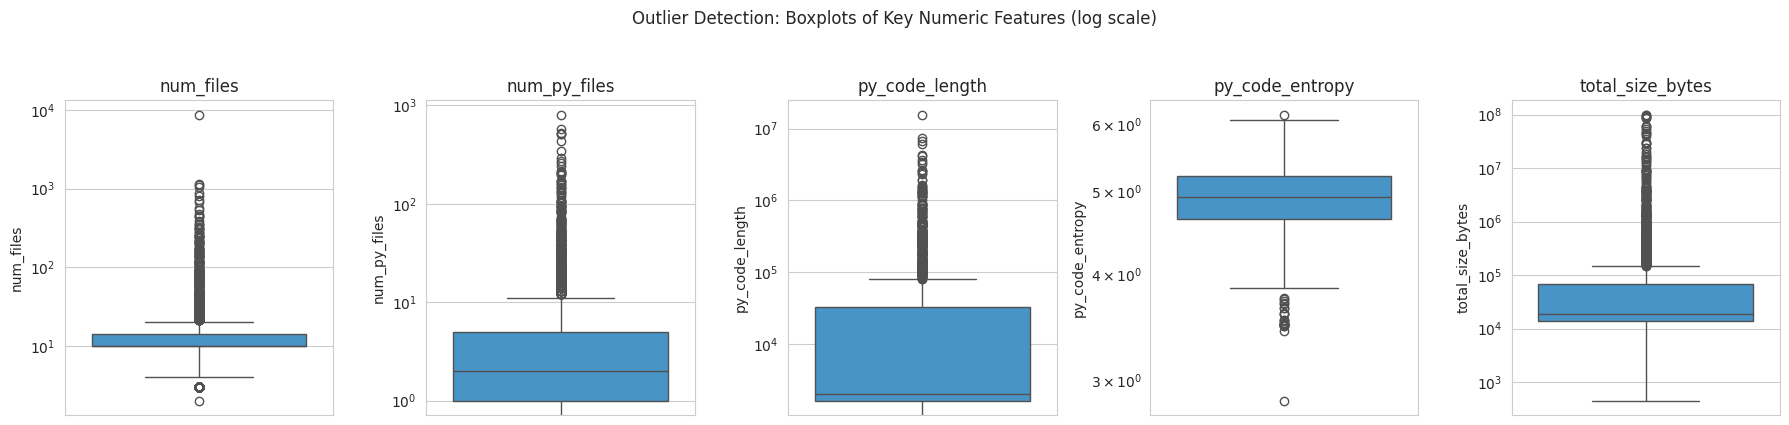

In [12]:
fig, axes = plt.subplots(1, len(numeric_check_cols), figsize=(18, 4))
for i, col in enumerate(numeric_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(col)
    axes[i].set_yscale("log")
plt.suptitle("Outlier Detection: Boxplots of Key Numeric Features (log scale)", y=1.05)
plt.tight_layout()
plt.savefig("cleaning_outlier_boxplots.png", dpi=120)
plt.show()


**Decision: outliers are retained, not removed.**

Unlike typical noisy survey/sensor data, an "outlier" here (e.g., an unusually large
`py_code_length` or `total_size_bytes`) is not necessarily an error — it can be a genuinely
large, legitimate package, or conversely, an unusually *small* package is itself one of the
strongest real signals of a malicious typosquat (as seen in the Phase 3 EDA boxplots earlier).
Removing these values would delete exactly the signal our model needs to learn. This is a
deliberate, justified cleaning decision, not an oversight — we detect and report outliers for
transparency, but do not blindly strip them.


In [13]:
def handle_missing_values(dataframe):
    """
    Standard missing-value handling strategy for this dataset, applied defensively
    even though the current data is complete.
    - Binary/indicator columns (has_*): missing -> 0 (assume absence of the pattern)
    - Numeric count/size columns: missing -> median (robust to outliers)
    - Categorical columns (label, package_name): missing rows are dropped, since
      a missing label makes a row unusable for supervised learning.
    """
    dataframe = dataframe.copy()
    binary_cols = [c for c in dataframe.columns if c.startswith("has_")]
    numeric_cols = [c for c in dataframe.select_dtypes(include=[np.number]).columns if c not in binary_cols]

    for col in binary_cols:
        dataframe[col] = dataframe[col].fillna(0)
    for col in numeric_cols:
        dataframe[col] = dataframe[col].fillna(dataframe[col].median())

    dataframe = dataframe.dropna(subset=["label"])
    return dataframe

df = handle_missing_values(df)
print("Missing value handling applied. Remaining missing values:", df.isnull().sum().sum())


Missing value handling applied. Remaining missing values: 0


## 4. Encoding

The target variable `label` is categorical (`malicious` / `benign`). We encode it into a
binary numeric column `label_encoded` (1 = malicious, 0 = benign) for use in ML models.


In [14]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

print("Encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df[["label", "label_encoded"]].drop_duplicates()


Encoding mapping: {'benign': np.int64(0), 'malicious': np.int64(1)}


,label,label_encoded
0,malicious,1
1500,benign,0


All other features (`has_eval`, `has_exec`, `has_setup_py`, etc.) are already numeric
binary indicators (0/1) produced directly during feature extraction, so no further categorical
encoding is required for them.


## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution

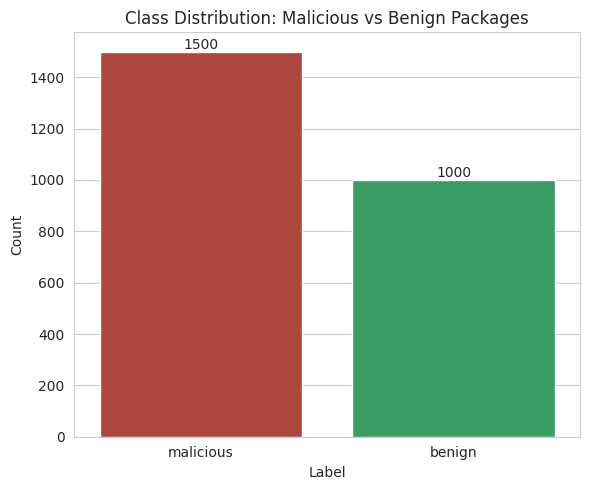

label
malicious    1500
benign       1000
Name: count, dtype: int64
label
malicious    60.0
benign       40.0
Name: proportion, dtype: float64 % of total


In [15]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x="label", hue="label", palette={"malicious": "#c0392b", "benign": "#27ae60"}, legend=False)
plt.title("Class Distribution: Malicious vs Benign Packages")
plt.xlabel("Label")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=120)
plt.show()

print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3) * 100, "% of total")


**Observation:** the dataset is imbalanced (60% malicious, 40% benign), which is the
opposite of real-world prevalence (malicious packages are actually rare). This is an intentional
sampling choice made during dataset construction to give the model enough malicious examples to
learn from, but it means we must evaluate with class-weighted or class-balanced metrics
(precision/recall per class) rather than relying on raw accuracy.


### 5.2 Distribution of Key Numeric Features by Class

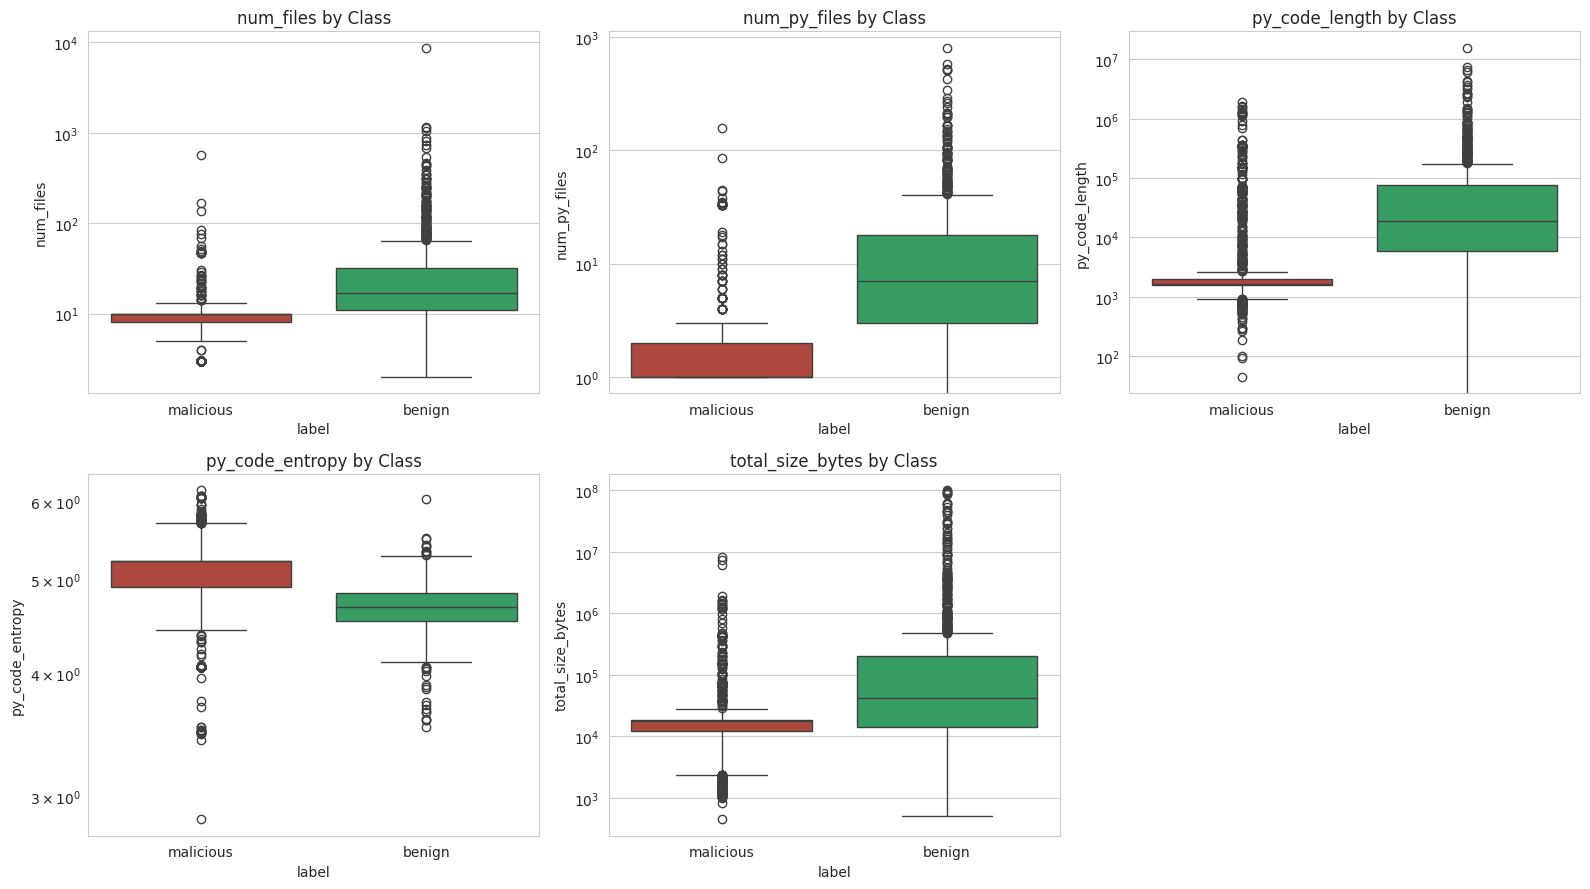

In [16]:
numeric_features_of_interest = ["num_files", "num_py_files", "py_code_length", "py_code_entropy", "total_size_bytes"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(numeric_features_of_interest):
    sns.boxplot(data=df, x="label", y=feat, hue="label", palette={"malicious": "#c0392b", "benign": "#27ae60"}, ax=axes[i], legend=False)
    axes[i].set_title(f"{feat} by Class")
    axes[i].set_yscale("log")  # log scale since these are heavily right-skewed

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("eda_boxplots_by_class.png", dpi=120)
plt.show()


**Observation:** malicious packages are systematically smaller and simpler than benign
ones — fewer files, fewer Python files, shorter total code length. This matches the intuition
that typosquatted malicious packages are often thin wrappers designed to look legitimate while
executing a small malicious payload, whereas real, actively maintained benign packages tend to
have fuller codebases, more files, and more substantial documentation.


### 5.3 Suspicious Indicator Prevalence by Class

<Figure size 900x800 with 0 Axes>

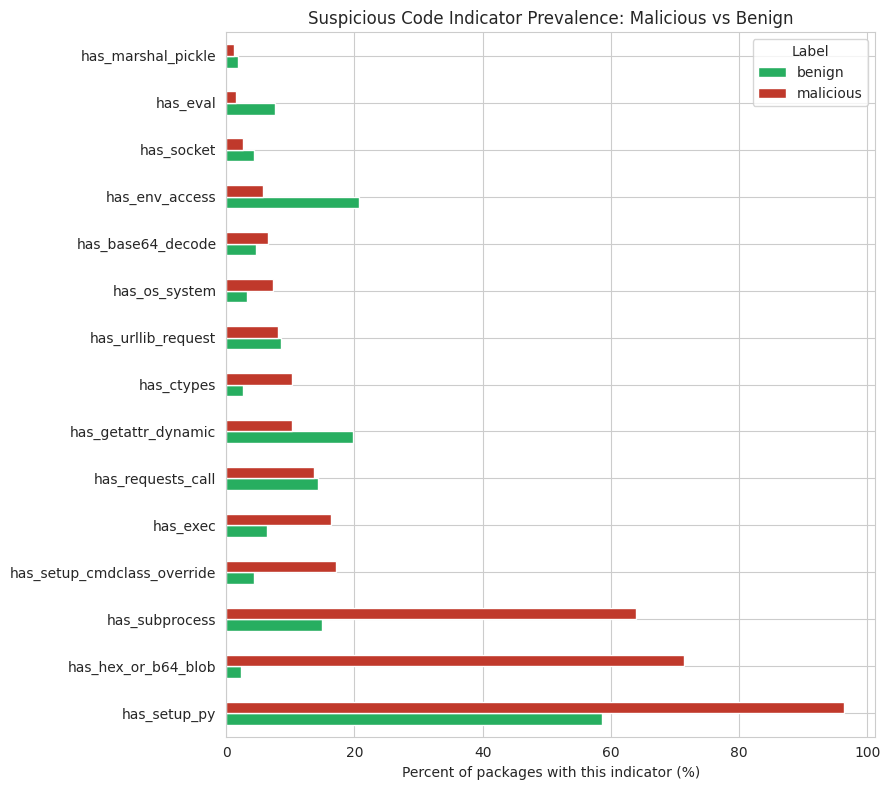

label,benign,malicious
has_setup_py,58.6,96.4
has_hex_or_b64_blob,2.3,71.5
has_subprocess,14.9,63.9
has_setup_cmdclass_override,4.3,17.2
has_exec,6.4,16.4
has_requests_call,14.3,13.7
has_getattr_dynamic,19.8,10.3
has_ctypes,2.6,10.3
has_urllib_request,8.5,8.1
has_os_system,3.3,7.3


In [17]:
suspicious_cols = [c for c in df.columns if c.startswith("has_")]

prevalence = df.groupby("label")[suspicious_cols].mean().T * 100
prevalence = prevalence.sort_values(by="malicious", ascending=False)

plt.figure(figsize=(9, 8))
prevalence.plot(kind="barh", figsize=(9, 8), color={"malicious": "#c0392b", "benign": "#27ae60"})
plt.xlabel("Percent of packages with this indicator (%)")
plt.title("Suspicious Code Indicator Prevalence: Malicious vs Benign")
plt.legend(title="Label")
plt.tight_layout()
plt.savefig("eda_indicator_prevalence.png", dpi=120)
plt.show()

prevalence.round(1)


### 5.4 Correlation Heatmap

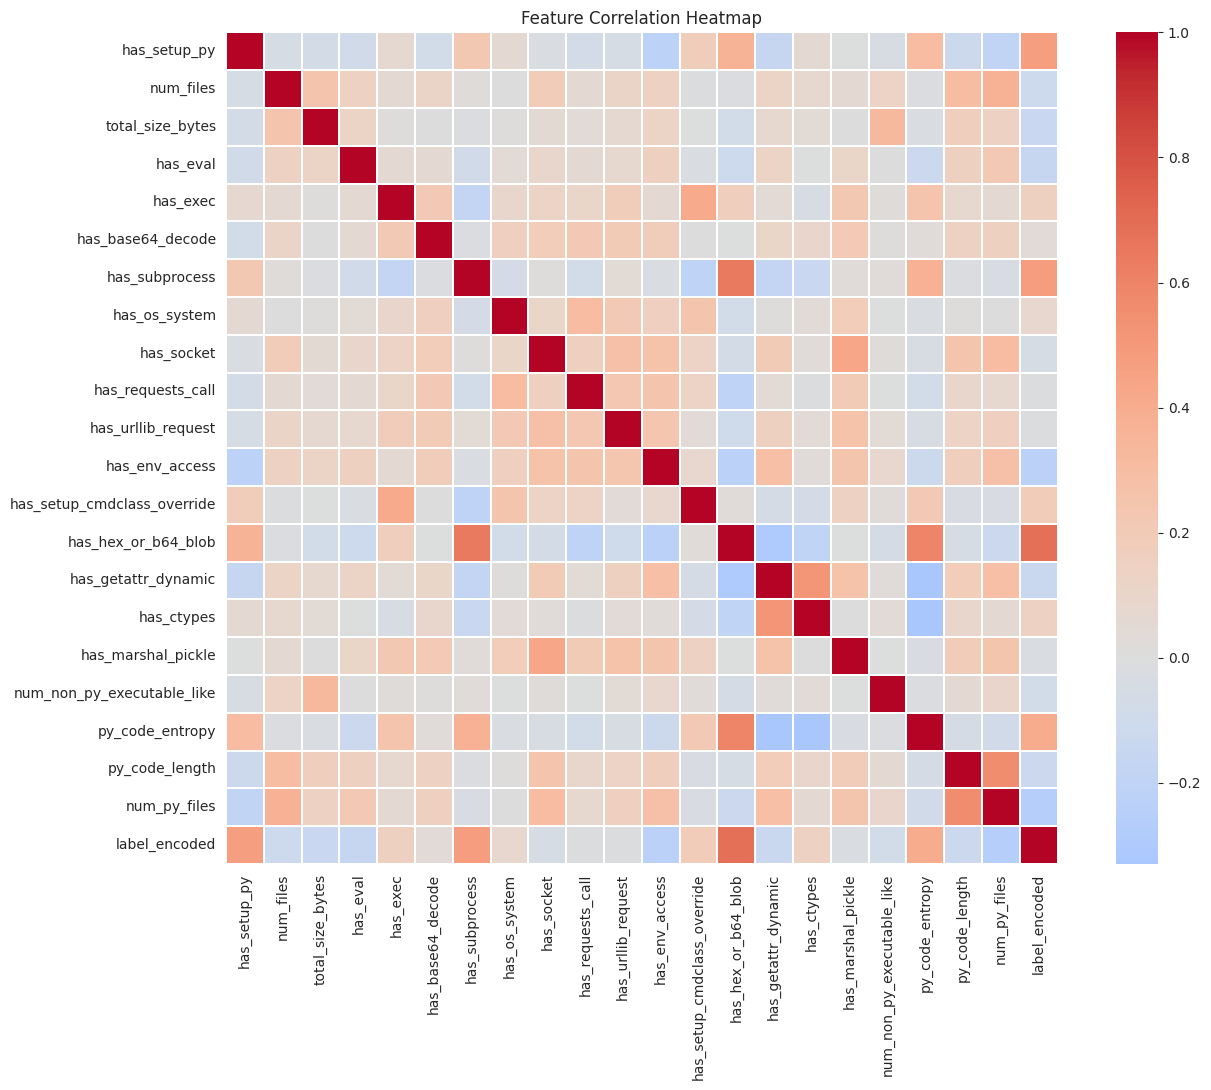

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "label_encoded" not in numeric_cols:
    numeric_cols.append("label_encoded")

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=120)
plt.show()


In [19]:
# Features most correlated with the target label
label_corr = corr["label_encoded"].drop("label_encoded").sort_values(key=abs, ascending=False)
print("Top 10 features most correlated with label_encoded (malicious=1):")
label_corr.head(10)


Top 10 features most correlated with label_encoded (malicious=1):


has_hex_or_b64_blob            0.682963
has_subprocess                 0.483557
has_setup_py                   0.474737
py_code_entropy                0.401374
num_py_files                  -0.257943
has_env_access                -0.227783
has_setup_cmdclass_override    0.194196
has_eval                      -0.154826
has_exec                       0.148642
has_ctypes                     0.145302
Name: label_encoded, dtype: float64

## 6. Feature Derivation

Beyond the 21 raw extracted features, we derive additional engineered features that may
capture patterns the raw features miss individually.


In [20]:
def derive_features(dataframe):
    dataframe = dataframe.copy()

    # Code density: how much code exists relative to file count
    # (malicious packages are often thin wrappers -> low code-per-file)
    dataframe["code_density"] = dataframe["py_code_length"] / dataframe["num_files"].replace(0, 1)

    # Ratio of Python files to total files (non-Python files can indicate binaries/scripts)
    dataframe["py_file_ratio"] = dataframe["num_py_files"] / dataframe["num_files"].replace(0, 1)

    # Total count of suspicious behavioral indicators triggered (aggregate risk score)
    suspicious_cols = [c for c in dataframe.columns if c.startswith("has_")]
    dataframe["suspicious_indicator_count"] = dataframe[suspicious_cols].sum(axis=1)

    # Average file size (total size / number of files)
    dataframe["avg_file_size"] = dataframe["total_size_bytes"] / dataframe["num_files"].replace(0, 1)

    # Flag: unusually small package (bottom decile of code length) -- common typosquat pattern
    threshold = dataframe["py_code_length"].quantile(0.10)
    dataframe["is_unusually_small"] = (dataframe["py_code_length"] <= threshold).astype(int)

    return dataframe

df = derive_features(df)
new_features = ["code_density", "py_file_ratio", "suspicious_indicator_count", "avg_file_size", "is_unusually_small"]
df[new_features].describe()


,code_density,py_file_ratio,suspicious_indicator_count,avg_file_size,is_unusually_small
count,2.500000e+03,2500.000000,2500.000000,2.500000e+03,2500.00000
mean,4.797368e+03,0.294922,2.693200,1.561821e+04,0.10000
std,3.942466e+04,0.232832,1.631238,1.241282e+05,0.30006
min,0.000000e+00,0.000000,0.000000,6.290000e+01,0.00000
25%,1.611000e+02,0.100000,2.000000,1.173029e+03,0.00000
50%,2.383651e+02,0.200000,3.000000,1.813650e+03,0.00000
75%,1.704216e+03,0.437500,3.000000,3.948490e+03,0.00000
max,1.425313e+06,0.990172,12.000000,3.568214e+06,1.00000


In [21]:
# Verify the derived features actually separate the classes (sanity check)
df.groupby("label")[new_features].mean().round(3)


,code_density,py_file_ratio,suspicious_indicator_count,avg_file_size,is_unusually_small
label,,,,,
benign,3564.899,0.433,1.743,27959.553,0.104
malicious,5619.014,0.203,3.327,7390.643,0.097


**Observation:** `suspicious_indicator_count` and `is_unusually_small` both show a
clear difference between classes, confirming these derived features carry real signal rather
than being redundant with the raw features.


## 7. Normalization / Scaling

Tree-based models (Random Forest, Gradient Boosting) are scale-invariant and don't require
normalization. However, distance-based and linear models (SVM, Logistic Regression, KNN, etc.)
are sensitive to feature scale — a feature like `total_size_bytes` (range: thousands to
hundreds of thousands) would dominate a binary 0/1 feature like `has_eval` if left unscaled.

We apply `StandardScaler` (zero mean, unit variance) to all numeric features, fit only on
the data that will be used for training to avoid data leakage.


In [22]:
feature_cols = [c for c in df.columns if c not in ("package_name", "label", "label_encoded")]
X = df[feature_cols]
y = df["label_encoded"]

print(f"Feature matrix shape: {X.shape}")
print(f"Feature columns ({len(feature_cols)}):")
print(feature_cols)


Feature matrix shape: (2500, 26)
Feature columns (26):
['has_setup_py', 'num_files', 'total_size_bytes', 'has_eval', 'has_exec', 'has_base64_decode', 'has_subprocess', 'has_os_system', 'has_socket', 'has_requests_call', 'has_urllib_request', 'has_env_access', 'has_setup_cmdclass_override', 'has_hex_or_b64_blob', 'has_getattr_dynamic', 'has_ctypes', 'has_marshal_pickle', 'num_non_py_executable_like', 'py_code_entropy', 'py_code_length', 'num_py_files', 'code_density', 'py_file_ratio', 'suspicious_indicator_count', 'avg_file_size', 'is_unusually_small']


In [23]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Before scaling (raw feature means and std):")
print(X.describe().loc[["mean", "std"]].T.head(6))

print("\nAfter scaling (should be ~0 mean, ~1 std):")
print(X_scaled.describe().loc[["mean", "std"]].T.head(6).round(3))


Before scaling (raw feature means and std):
                          mean           std
has_setup_py            0.8128  3.901500e-01
num_files              26.5208  1.849772e+02
total_size_bytes   711123.6840  5.730669e+06
has_eval                0.0392  1.941093e-01
has_exec                0.1240  3.296475e-01
has_base64_decode       0.0576  2.330321e-01

After scaling (should be ~0 mean, ~1 std):
                   mean  std
has_setup_py        0.0  1.0
num_files           0.0  1.0
total_size_bytes   -0.0  1.0
has_eval            0.0  1.0
has_exec           -0.0  1.0
has_base64_decode  -0.0  1.0


**Note:** for our final modeling pipeline (Phase 4), scaling will be applied *inside*
a `sklearn.pipeline.Pipeline` fitted separately within each cross-validation fold, rather than
on the full dataset up front as shown here for demonstration — this prevents information from
the test fold leaking into the training fold via the scaler's fitted mean/variance.


## 8. Save Transformed Dataset

We save the cleaned, encoded, and feature-engineered dataset for use in Phase 4 (Model
Development & Evaluation).


In [24]:
df.to_csv("pypi_dataset_transformed.csv", index=False)
groups_df.to_csv("package_groups_for_split.csv", index=False)
print(f"Saved transformed dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Saved groups reference file: {groups_df.shape[0]} rows")
df.head()


Saved transformed dataset: 2500 rows, 29 columns
Saved groups reference file: 2500 rows


,has_setup_py,num_files,total_size_bytes,has_eval,has_exec,has_base64_decode,has_subprocess,has_os_system,has_socket,has_requests_call,has_urllib_request,has_env_access,has_setup_cmdclass_override,has_hex_or_b64_blob,has_getattr_dynamic,has_ctypes,has_marshal_pickle,num_non_py_executable_like,py_code_entropy,py_code_length,num_py_files,package_name,label,label_encoded,code_density,py_file_ratio,suspicious_indicator_count,avg_file_size,is_unusually_small
0,1,10,17999,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.215,1611,1,selfcraftint,malicious,1,161.10,0.100000,3,1799.900000,0
1,1,10,17076,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.210,1578,1,urlvm,malicious,1,157.80,0.100000,3,1707.600000,0
2,1,10,152115,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.506,150832,2,settinginmaass,malicious,1,15083.20,0.200000,2,15211.500000,0
3,1,12,2402,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,4.889,993,2,pytest-tt-ddriven,malicious,1,82.75,0.166667,3,200.166667,1
4,1,10,17616,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,5.217,1609,1,esqccinfo,malicious,1,160.90,0.100000,3,1761.600000,0


## 9. Summary

- **Missing values:** none found; a defensive handling strategy was defined for robustness on future data.
- **Encoding:** target label encoded to binary (`label_encoded`); all other features were already numeric.
- **EDA:** revealed that malicious packages are structurally smaller/simpler than benign ones,
  and that specific behavioral indicators (e.g. `has_setup_cmdclass_override`) show meaningfully
  different prevalence between classes.
- **Feature derivation:** 5 new engineered features created (`code_density`, `py_file_ratio`,
  `suspicious_indicator_count`, `avg_file_size`, `is_unusually_small`), validated to carry
  real class-separating signal.
- **Scaling:** `StandardScaler` demonstrated and will be applied per-fold in Phase 4 to avoid leakage.

This transformed dataset (`pypi_dataset_transformed.csv`) is now ready for model training and
evaluation in Phase 4.
